In [30]:
# Import des bibliothèques essentielles pour le machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


<span style="color:#00008B;">

# 1 Classification #

We will use the dataset <b>"student_drop_out.csv"</b> that you can find here:

</span>

https://archive.ics.uci.edu/dataset/697

<span style="color:#00008B;">

Get familiar with the dataset. Each line correspond to a student with information at the time of enrollement in a high-education program.<br>
The label to predict is the "Target" attribute, being the status of the student at the time when he should finish his study program. There are three classes: "Dropout" (the student has dropped out), "Enrolled" (the student is still enrolled), and "Graduate" (the student has successfully finished his studies).

</span>

<span style="color:#00008B;">

## Question 1 ##
 
We will train a binary classification model, with class 0: "Droput" and class 1: "Enrolled" or "Graduate".  Load the datset into pandas DataFRame, and prepare it for classification.

</span>

<span style="color:#00008B;">

## Question 2 ##

Visualise the data such that you can see if any features are redundant and the overall distribution  of the features within the two classes. You may need to normalise the values of each attribute. Interpret the results.

</span>

<span style="color:#00008B;">

### Interpretation: ###
</span>

<span style="color:#00008B;">

## Question 3 ##
Split the dataset into a training  set (90%) and a test set (10%) and train a classifier using the algorithm of your choice. Calculate the classifiers accuracy on the trainning and test set.

Explain the algorithm. Where does the difference between the trainning and test accuracy come from?

</span>



<span style="color:#00008B;">

## Question 4 ##

Change the random seed of the train/test split.<br>
Why is the result different? Do a more thorough evaluation aggreagating several different splits.

</span>


<span style="color:#00008B;">

## Question 5 ##

Compute the confusion matrix on your test set predictions (normalising each row sum to 1), and explain it.<br>
What are the true/false positives (TP/FP) and true/false negatives (TN/FN)?<br>
Compute the F1 score. What is the advantage compared to the accuracy measure?

</span>

<span style="color:#00008B;">

## Question 6 ##

Retrain your classifier with only 1% of the training set, and evaluate it on the same test set.<br> 
Why is the result worse? Can it be improved by decreasing the complexity of the classifier?

</span>

<span style="color:#00008B;">

# 2 Regresssion #

We will now use the dataset called <b>"measurements.csv"</b> that you can download from moodle.

It is composed of a two-dimensional data wich we will try to approximate via diffferent regression models.<br>
 We will minimise our empirical risk using the east Squares algorithm implemented  in the Linear Regression class of sklearn. 

</span>

<span style="color:#00008B;">

## Question 7 ##

Load the dataset (scatter plot). Then perform a linear regression using:<br>
<b><span style="color:#FFA05C;">sklearn.linear_model.LinearRegression. </span></b>

Compute the mean squared error and the R² score (coefficient of determination).<br>
Plot the estimated line together with the data points, and interpret the result.

</span>


<span style="color:#00008B;">

## Question 8 ##

We will now use the class PolynomialFeatures to do polynomialregression:<br>
<em><b><span style="color:#FFA05C"> from </span> <span style="color:#CD7DDE"> sklearn.preporcessing </span> <span style="color:#FFA05C"> import </span> <span style="color:#CD7DDE">  PolynomialFeatures </span></b></em>

Perform a series of polynomial regressions with increasing degrees, e.g 2, 8, 25. Compuute the corresponding MSE and R² abd plot the curves. <br>
Interpret the results. Why does Empirical Risk Minimisation fail when the hypothesis space is too large? <br>
<em>Useful functions to draw a polynomial with coeeficient in p (in order of decreasing degree):</em>
</span>
<br><br>
<span style="color:#57524C;">
x = np.linspace(0, 15, num=200)<br>
p = np.append(np.flip(poly_reg_model.coef_), (poly_reg_model.intercept_))<br>
y3 = np.polyval(p, x)
</span>


In [31]:
input_file = "measurements.csv"

df = pd.read_csv(input_file, header = 0)

In [32]:
df

,0,1
0,0.0,0.50
1,1.0,0.90
2,2.0,1.60
3,3.0,2.30
4,4.0,2.20
5,5.0,1.80
6,6.0,1.50
7,7.0,1.80
8,8.0,2.50
9,9.0,3.00


In [33]:
df.shape


(16, 2)

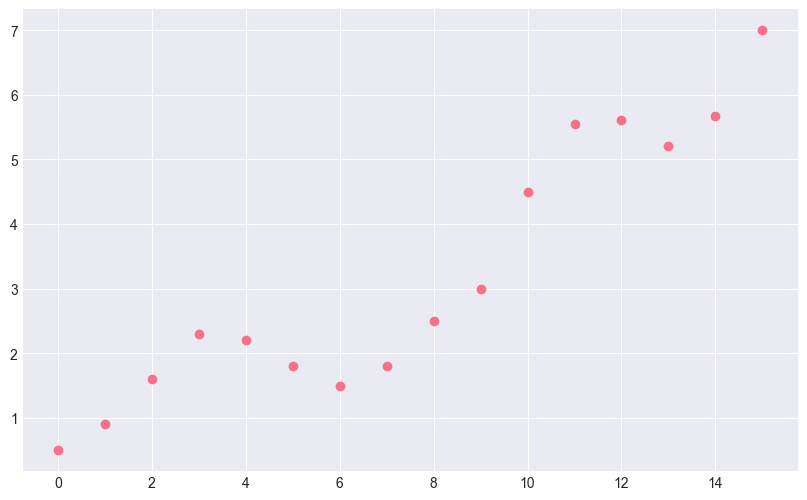

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(df['0'], df['1'])
plt.show()

R² Score : 0.9946
MSE      : 0.0209


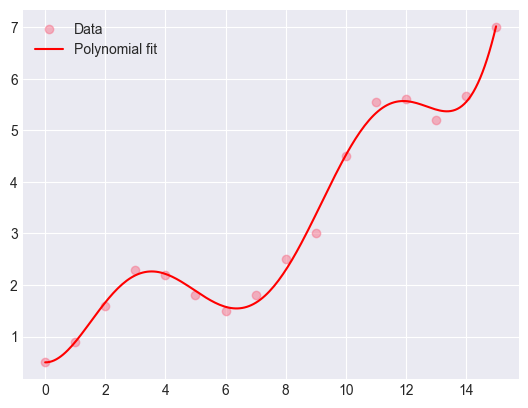

In [ ]:
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("poly", PolynomialFeatures(degree=8, include_bias=False)),
    ("linear", LinearRegression()),
])
#.values.reshape(-1, 1) transforme une sliece d'un dataframe pandas en un array numpy de une dimension, puis reshape(-1, 1) transforme ce array en une matrice à une colonne. Au funal on obtient un array numpy, ce qui est necesaire por sklarn
df_0 = df['0'].values.reshape(-1, 1)
df_1 = df['1'].values.reshape(-1, 1)

model.fit(df_0, df_1)
y_pred = model.predict(df_0)

print(f"R² Score : {r2_score(df_1, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(df_1, y_pred):.4f}")

# Plot
X_plot = np.linspace(0, 15, 200).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.scatter(df_0, df_1, alpha=0.5, label="Data")
plt.plot(X_plot, y_plot, color="red", label="Polynomial fit")

plt.legend()
plt.show()

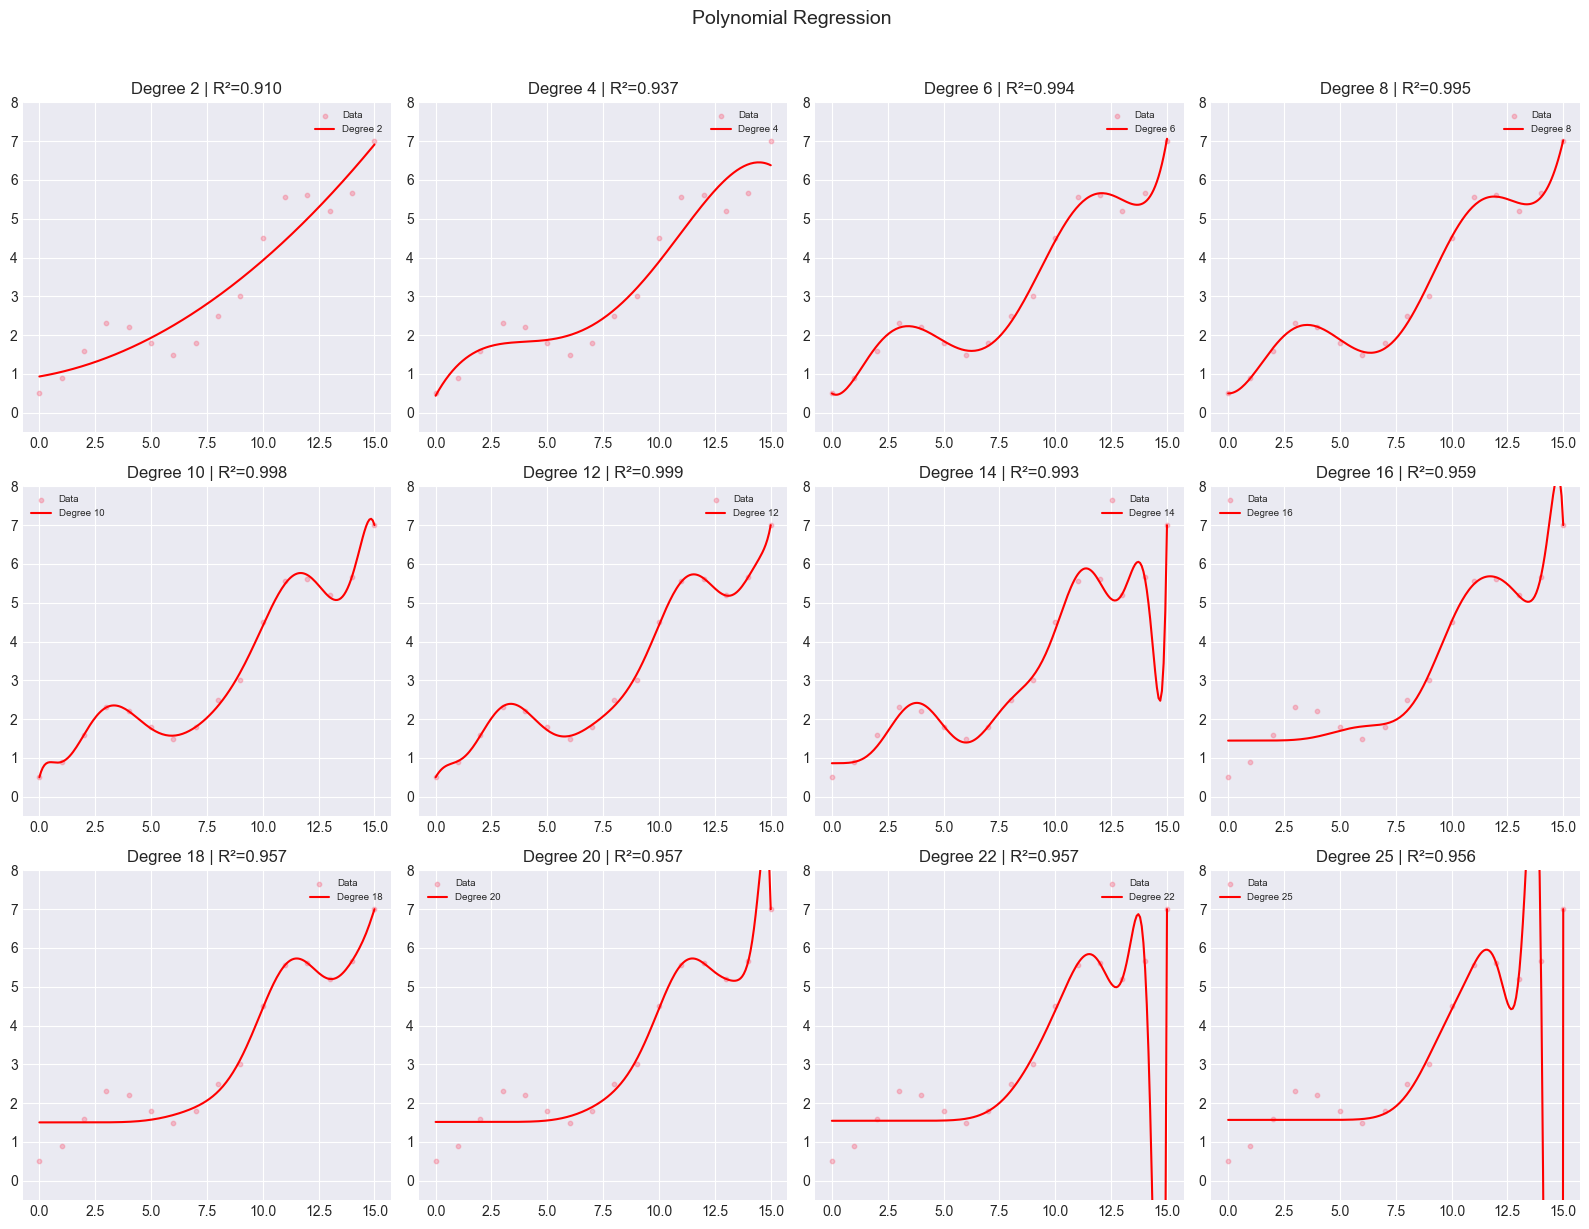

 Degree     R²    MSE
      2 0.9102 0.3472
      4 0.9373 0.2424
      6 0.9937 0.0244
      8 0.9946 0.0209
     10 0.9983 0.0066
     12 0.9988 0.0045
     14 0.9933 0.0259
     16 0.9585 0.1602
     18 0.9573 0.1648
     20 0.9573 0.1652
     22 0.9568 0.1670
     25 0.9559 0.1704


In [57]:
degrees = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 25]

df_0 = df['0'].values.reshape(-1, 1)
df_1 = df['1'].values.reshape(-1, 1)

results = []

# --- Plots ---
n = len(degrees)
cols = 4
rows = (n + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, degree in enumerate(degrees):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression()),
    ])
    model.fit(df_0, df_1)
    y_pred = model.predict(df_0)
    
    y_plot = model.predict(X_plot)
    X_plot = np.linspace(0, 15, 200).reshape(-1, 1)

    r2  = r2_score(df_1, y_pred)
    mse = mean_squared_error(df_1, y_pred)
    results.append({"Degree": degree, "R²": round(r2, 4), "MSE": round(mse, 4)})

    ax = axes[i]
    ax.scatter(df_0, df_1, alpha=0.4, s=10, label="Data")
    ax.plot(X_plot, y_plot, color="red", label=f"Degree {degree}")
    ax.set_title(f"Degree {degree} | R²={r2:.3f}")
    ax.set_ylim(df_1.min() - 1, df_1.max() + 1)  # consistent y-axis
    ax.legend(fontsize=7)

plt.suptitle("Polynomial Regression ", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Metrics Table ---
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

In [60]:
#.values.reshape(-1, 1) transforme une sliece d'un dataframe pandas en un array numpy de une dimension, puis reshape(-1, 1) transforme ce array en une matrice à une colonne. Au funal on obtient un array numpy, ce qui est necesaire por sklarn
df_0 = df['0'].values.reshape(-1, 1)
df_1 = df['1'].values.reshape(-1, 1)


poly = PolynomialFeatures(degree=8, include_bias=False)
X_poly = poly.fit_transform(df_0)  


model = LinearRegression()
model.fit(X_poly, df_1)


y_pred = model.predict(X_poly)


X_plot_poly = poly.transform(X_plot)  # solo transform
y_plot = model.predict(X_plot_poly)

print(f"R² Score : {r2_score(df_1, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(df_1, y_pred):.4f}")


x = np.linspace(0, 15, num=200)
p = np.append(np.flip(model.coef_), (model.intercept_))
y3 = np.polyval(p, x)

print(y3)

R² Score : 0.9946
MSE      : 0.0209
[0.49832141 0.49995357 0.5070513  0.51943406 0.53689566 0.55920728
 0.58612034 0.61736929 0.65267415 0.69174304 0.73427443 0.77995944
 0.82848381 0.87952992 0.93277861 0.98791086 1.04460944 1.10256036
 1.16145427 1.22098778 1.28086456 1.34079653 1.40050476 1.45972044
 1.51818566 1.57565417 1.63189198 1.686678   1.7398045  1.79107753
 1.8403173  1.88735844 1.93205025 1.97425684 2.01385726 2.05074554
 2.08483066 2.11603653 2.14430185 2.16958002 2.19183885 2.2110604
 2.22724071 2.24038941 2.25052946 2.25769674 2.26193961 2.26331853
 2.26190557 2.2577839  2.25104734 2.24179979 2.23015468 2.21623446
 2.20016995 2.18209983 2.16216997 2.14053289 2.1173471  2.0927765
 2.06698973 2.04015959 2.01246238 1.9840773  1.95518578 1.92597091
 1.89661679 1.86730796 1.83822874 1.8095627  1.78149202 1.75419696
 1.7278553  1.70264173 1.67872742 1.65627941 1.63546017 1.61642707
 1.59933196 1.58432069 1.5715327  1.56110059 1.55314976 1.54779804
 1.54515532 1.5453233  1.548